# Notebook 2: Preprocessing Pipeline, K-Means Clustering, and Theory Questions

**Course:** Data Engineering - Unsupervised Learning Project
**University:** Bar-Ilan University, Spring 2026
**Dataset:** NYC PLUTO - 858,644 lots/buildings across New York City
**Team scope:** This notebook covers (1) the final preprocessing pipeline, (2) K-Means clustering analysis, and (3) theory questions from Sections 1 and 4 of the course tutorial.

## Sections Covered

- **Section 1**: Data loading and feature role definitions
- **Section 2**: Numeric conversion and coded-missing replacement
- **Section 3**: Outlier capping (IQR winsorization)
- **Section 4**: Feature engineering
- **Section 5**: Missing-value removal and log transformation
- **Section 6**: Clustering feature matrix (`landuse` excluded) and standardization
- **Section 7**: PCA (secondary dimensionality-reduction experiment)
- **Section 8**: K-Means: hyperparameters, elbow, silhouette, initialization sensitivity
- **Section 9**: Saving results and final summary
- **Section 10**: Theory questions

## Research Question

How can we build, from the physical, functional, and geographical characteristics of the PLUTO dataset,
an unsupervised segmentation of NYC buildings to identify homogeneous urban profiles and analyze
their distribution across the five boroughs?

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

## Section 1: Data Loading and Feature Role Definitions

In [2]:
# Locate the project root by walking up from the notebook's working directory.
# This makes the notebook runnable whether Jupyter is launched from the project
# root or from the notebook's own directory.
_search = Path.cwd()
for _ in range(5):
    if (_search / 'data' / 'raw').is_dir():
        PROJECT_ROOT = _search
        break
    _search = _search.parent
else:
    raise RuntimeError('Could not locate project root (expected a data/raw/ subdirectory).')

RAW_PATH       = PROJECT_ROOT / 'data' / 'raw' / 'pluto_working_copy.csv'
PROCESSED_DIR  = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR    = PROJECT_ROOT / 'reports' / 'figures'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(RAW_PATH, low_memory=False)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
print(f'First 10 columns: {list(df_raw.columns[:10])}')

Dataset loaded: 858,644 rows, 101 columns
First 10 columns: ['borough', 'Tax block', 'Tax lot', 'community board', 'census tract 2010', 'cb2010', 'schooldist', 'council district', 'postcode', 'firecomp']


### Feature role definitions

Features are split into two non-overlapping roles before any transformation:

| Role | Features | Rationale |
|---|---|---|
| **Clustering input** | 13 source numerics + 3 engineered (16 total) | Measured physical and functional building characteristics |
| **Post-clustering only** | `borough`, `postcode`, `community board`, `latitude`, `longitude`, `assesstot`, `landuse` | Geographic, value, and categorical context reserved for blind validation after cluster assignment |

**Why exclude `borough` from clustering?**  
Borough is a coarse administrative label, not a building characteristic. Including it would bias K-Means toward geographic sub-regions rather than meaningful building typologies.

**Why exclude `landuse` from clustering?**  
`landuse` is a categorical label summarizing predominant use. Included as one-hot input, it dominates the distance calculation and K-Means simply recovers the input categories: cluster sizes mirror landuse-code frequencies rather than building morphology. `landuse` is instead used for blind validation - cross-tabulated against the discovered clusters in Section 9 to show what the morphology-based groups correspond to.

**Why exclude `assesstot` from clustering?**  
Total assessed value would reduce the segmentation to value-based groups, collapsing the problem into a form of regression. It is reserved for post-hoc cluster profiling.

In [3]:
# Source numeric columns needed before engineering
SOURCE_NUMERIC = [
    'lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth',
    'yearbuilt',
    'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea',
]

# Engineered clustering features (derived below)
ENGINEERED = ['building_age', 'building_density', 'residential_ratio']

# Clustering features: 16 numeric dimensions only.
# landuse is intentionally excluded; see Section 6 for the rationale.
CLUSTER_NUMERIC = [
    'lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth',
    'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea',
    'building_age', 'building_density', 'residential_ratio',
]

# Columns that receive log1p before scaling
LOG_COLS = [
    'lotarea', 'bldgarea', 'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_density',
]

# Post-clustering interpretation columns (never fed to K-Means).
# landuse is here for blind post-hoc validation against discovered clusters.
POST_CLUSTER = [
    'borough', 'postcode', 'community board',
    'latitude', 'longitude', 'assesstot', 'landuse',
]

# Lot identifier
ID_COL = 'BBL'

# Columns to winsorize (IQR capping)
WINSORISE_COLS = ['lotfront', 'lotdepth', 'lotarea', 'bldgarea', 'unitstotal', 'resarea', 'yearbuilt']

# Columns to load from the raw CSV
LOAD_COLS = [ID_COL] + SOURCE_NUMERIC + POST_CLUSTER

# Verify all requested columns exist
missing_cols = [c for c in LOAD_COLS if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f'Columns not found in raw CSV: {missing_cols}')
print('All required columns present.')
print(f'Loading {len(LOAD_COLS)} columns from the raw dataset.')

df = df_raw[LOAD_COLS].copy()
print(f'Working frame shape: {df.shape}')

All required columns present.
Loading 22 columns from the raw dataset.
Working frame shape: (858644, 22)


## Section 2: Numeric Conversion and Coded-Missing Replacement

### 2.1 Numeric conversion

The raw CSV was exported with a Narrow No-Break Space (U+202F) as a thousands separator,
which is a French locale artifact. Values such as `"2 660"` must be stripped before conversion.
We use a regex that removes all whitespace variants (ASCII space, U+202F, U+00A0) and any
non-numeric character, then pass `errors='coerce'` so unparseable values become NaN.

In [4]:
# Strip thousands-separator whitespace and coerce to numeric
numeric_to_convert = SOURCE_NUMERIC + ['assesstot', 'latitude', 'longitude', 'postcode']

for col in numeric_to_convert:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
                   .str.replace(r'[\s\u202f\u00a0]', '', regex=True)
                   .str.replace(r'[^\d.\-]', '', regex=True)
                   .replace('', np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Numeric conversion complete.')
print('dtypes sample:')
print(df[SOURCE_NUMERIC[:6]].dtypes)

Numeric conversion complete.
dtypes sample:
lotarea      float64
bldgarea     float64
numfloors    float64
lotfront     float64
lotdepth     float64
yearbuilt    float64
dtype: object


### 2.2 Replace coded-missing zeros with NaN

The PLUTO data dictionary documents `yearbuilt = 0` as "year unknown" and `bldgarea = 0` as
an unpopulated field. Both encode absence of information, not a real measurement of zero.
Treating them as zero would pull centroids toward nonsensical values (an age of 2026 years,
a building with no floor area). Replacing them with NaN lets the missing-value drop in
Section 5 handle them correctly.

In [5]:
n_yearbuilt_zero = (df['yearbuilt'] == 0).sum()
n_bldgarea_zero  = (df['bldgarea']  == 0).sum()

df.loc[df['yearbuilt'] == 0, 'yearbuilt'] = np.nan
df.loc[df['bldgarea']  == 0, 'bldgarea']  = np.nan

print(f'yearbuilt == 0 replaced with NaN: {n_yearbuilt_zero:,} rows ({n_yearbuilt_zero/len(df)*100:.2f}%)')
print(f'bldgarea  == 0 replaced with NaN: {n_bldgarea_zero:,}  rows ({n_bldgarea_zero/len(df)*100:.2f}%)')

yearbuilt == 0 replaced with NaN: 40,115 rows (4.67%)
bldgarea  == 0 replaced with NaN: 41,109  rows (4.79%)


## Section 3: Outlier Capping (IQR Winsorization)

### Why cap rather than delete?

EDA Notebook 2 detected extreme right-skew and IQR outliers on several area and count features.
Deleting outlier rows would discard up to 17% of the dataset for a single feature; the intersection
across features would remove far more. Winsorization (capping at Q1 - 1.5*IQR and Q3 + 1.5*IQR)
retains every row and limits the influence of extreme values without discarding information.

The EDA outlier analysis ranks `lotdepth` (23.83% IQR outliers) and `lotfront` (21.64%) as
the two highest-outlier features, followed by `numfloors`, `unitstotal`, `lotarea`, `bldgarea`,
`resarea`, and `yearbuilt`. All seven are winsorized with IQR capping here.
`numfloors` is handled separately: a hard cap at 104 floors removes parsing artifacts (One World
Trade Center is the tallest real building), extended by an additional landuse-1 sanity cap of
4 floors in Section 3b, extending the EDA cap at 104 with a building-type-specific correction.

In [6]:
# Hard cap: numfloors > 104 are data-entry artifacts, not real buildings
n_floors_capped = (df['numfloors'] > 104).sum()
df.loc[df['numfloors'] > 104, 'numfloors'] = np.nan
print(f'numfloors > 104 set to NaN: {n_floors_capped:,} rows')

# IQR winsorization for the seven highest-outlier features
cap_stats = []
for col in WINSORISE_COLS:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_lo = (df[col] < lo).sum()
    n_hi = (df[col] > hi).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    cap_stats.append({'feature': col, 'lower_cap': round(lo, 2), 'upper_cap': round(hi, 2),
                      'rows_capped_low': n_lo, 'rows_capped_high': n_hi})

print('\nIQR capping summary:')
print(pd.DataFrame(cap_stats).to_string(index=False))

numfloors > 104 set to NaN: 27,069 rows

IQR capping summary:
   feature  lower_cap  upper_cap  rows_capped_low  rows_capped_high
  lotfront     -262.5      501.5                0            185813
  lotdepth       14.5      242.5             2849            201785
   lotarea    -1000.0     7000.0                0             74061
  bldgarea     -987.5     5592.5                0             90052
unitstotal       -0.5        3.5                0            110558
   resarea     -590.0     4354.0                0             74429
 yearbuilt     1860.0     2020.0             4037              5911


In [7]:
# Diagnostic: numfloors distribution and implausible values by landuse code.
# Purpose: identify the scale of data-entry errors before choosing a cleaning rule.
# Note: values > 104 have already been set to NaN in the cell above.
print('numfloors summary (after cap at 104):')
print(df['numfloors'].describe().round(2))
print(f'Rows with numfloors NaN: {df["numfloors"].isna().sum():,}')

lu_totals = df['landuse'].value_counts().sort_index()

for t in [6, 10, 20]:
    above = df[df['numfloors'] > t]
    n_total = len(above)
    lu_above = above['landuse'].value_counts().sort_index()
    diag = pd.DataFrame({
        'count_above': lu_above,
        'pct_of_landuse': (lu_above / lu_totals * 100).round(1),
    }).dropna()
    print(f'\nnumfloors > {t}: {n_total:,} buildings ({n_total / len(df) * 100:.1f}% of all rows)')
    print(diag.to_string())

numfloors summary (after cap at 104):
count    789212.00
mean          5.28
std           7.50
min           0.00
25%           2.00
50%           2.00
75%           3.00
max         104.00
Name: numfloors, dtype: float64
Rows with numfloors NaN: 69,432

numfloors > 6: 117,620 buildings (13.7% of all rows)
         count_above  pct_of_landuse
landuse                             
1.0            99566            17.6
2.0             4143             3.1
3.0             4735            35.4
4.0             5312             9.4
5.0             2615            12.3
6.0              211             2.3
7.0               36             0.6
8.0              902             7.5
9.0                9             0.2
10.0              40             0.4
11.0               1             0.0

numfloors > 10: 111,630 buildings (13.0% of all rows)
         count_above  pct_of_landuse
landuse                             
1.0            99561            17.6
2.0             4031             3.1
3.0     

In [8]:
# Targeted numfloors correction: landuse 1 (one/two-family buildings) only.
# One and two-family homes cannot physically have more than 4 floors.
# Values above 4 for landuse 1 are data-entry errors, likely copied from an adjacent
# high-rise or entered at block level rather than building level.
# All other landuse codes are left untouched: genuine high-rises live in landuse 3
# (multi-family elevator) and must not be affected.
# Rows set to NaN here are removed at the existing dropna step in Section 5.
mask_lu1_high = (df['landuse'] == 1) & (df['numfloors'] > 4)
n_corrected = int(mask_lu1_high.sum())
df.loc[mask_lu1_high, 'numfloors'] = np.nan

print(f'numfloors > 4 set to NaN for landuse 1: {n_corrected:,} rows ({n_corrected / len(df) * 100:.2f}%)')
print('These rows will be removed at the dropna step (numfloors is a clustering feature).')

print('\nnumfloors summary after correction (landuse 1 capped at 4):')
print(df['numfloors'].describe().round(2))

print('\nSanity check - max numfloors by landuse after correction:')
print(df.groupby('landuse')['numfloors'].max().sort_index().round(1))

numfloors > 4 set to NaN for landuse 1: 100,238 rows (11.67%)
These rows will be removed at the dropna step (numfloors is a clustering feature).

numfloors summary after correction (landuse 1 capped at 4):


count    688974.00
mean          2.73
std           3.26
min           0.00
25%           2.00
50%           2.00
75%           3.00
max         104.00
Name: numfloors, dtype: float64

Sanity check - max numfloors by landuse after correction:
landuse
1.0       4.0
2.0      65.0
3.0      95.0
4.0      98.0
5.0     104.0
6.0      45.0
7.0      25.0
8.0      75.0
9.0      45.0
10.0     25.0
11.0     15.0
Name: numfloors, dtype: float64


## Section 4: Feature Engineering

Three derived features are created from the winsorized source columns, before any log transform.
This order matters: log1p compresses values, which would change the denominators and numerators
used in the ratios and the age computation.

| Feature | Formula | Interpretation |
|---|---|---|
| `building_age` | `2026 - yearbuilt` | Years elapsed since construction; 2026 is the analysis reference year |
| `building_density` | `bldgarea / lotarea` | Floor-area ratio proxy; how intensively a lot is built upon |
| `residential_ratio` | `clip(unitsres / unitstotal, 0, 1)` | Share of residential units; 0 = unit-less building, 1 = purely residential |

**NaN vs zero semantics for `residential_ratio`:**
A building with `unitstotal == 0` (e.g. a parking lot, vacant land, utility infrastructure)
has no units at all, making it 0% residential. This is a real, informative value, not missing
data. NaN is reserved strictly for rows where `unitstotal` or `unitsres` is itself absent
from the source.

**Clipping to [0, 1]:** `unitstotal` was winsorized (denominator capped at Q3 + 1.5*IQR)
but `unitsres` was not, so in some rows `unitsres` can exceed the winsorized `unitstotal`,
producing a ratio above 1. A building cannot be more than 100% residential by units, so
the ratio is clipped to [0, 1] after computation. This correction feeds through to the
clustering matrix and the cluster profiles.

Both ratio features use `np.where` with explicit NaN branches, and an extra `replace` call
removes any residual Inf values that could slip through winsorization near-zero edge cases
(`dropna` does not catch Inf).

**Traceability note:** the Phase 1 EDA defined `residential_ratio` but treated buildings with
`unitstotal == 0` as NaN. This notebook refines that definition by assigning 0.0 instead,
since a building with no units is genuinely 0% residential rather than missing information.

In [9]:
# building_age: yearbuilt already NaN where year was unknown (0)
df['building_age'] = 2026 - df['yearbuilt']

# building_density: NaN when lot has no area (np.where avoids inf)
df['building_density'] = np.where(
    df['lotarea'].notna() & (df['lotarea'] > 0),
    df['bldgarea'] / df['lotarea'],
    np.nan
)

# residential_ratio: unitsres / unitstotal (NOT resarea / bldgarea)
#   - NaN  when either unitstotal or unitsres is genuinely missing
#   - 0.0  when unitstotal == 0: the building has no units (parking lot, vacant land,
#          utility site); it is 0% residential, not missing information.
#   - ratio when unitstotal > 0, then clipped to [0, 1]
#
# Clipping is necessary because unitstotal (denominator) was winsorized but unitsres
# (numerator) was not. In rows where unitsres exceeds the capped unitstotal the raw
# ratio exceeds 1, which is physically impossible. clip(0, 1) corrects this without
# discarding the row, and the corrected value feeds both clustering and profiles.
df['residential_ratio'] = np.where(
    df['unitstotal'].isna() | df['unitsres'].isna(),
    np.nan,
    np.where(
        df['unitstotal'] > 0,
        df['unitsres'] / df['unitstotal'],
        0.0
    )
)
df['residential_ratio'] = df['residential_ratio'].clip(lower=0.0, upper=1.0)

# Safety: replace any Inf that could survive winsorization near-zero edges.
# dropna does not catch Inf, so this guard is necessary.
df[ENGINEERED] = df[ENGINEERED].replace([np.inf, -np.inf], np.nan)

# Confirm residential_ratio is bounded
rr = df['residential_ratio'].dropna()
print(f'residential_ratio range after clip: [{rr.min():.4f}, {rr.max():.4f}]  (must be [0, 1])')
print('Engineered feature statistics:')
df[ENGINEERED].describe().round(3)

residential_ratio range after clip: [0.0000, 1.0000]  (must be [0, 1])
Engineered feature statistics:


,building_age,building_density,residential_ratio
count,818203.000,816739.000,858199.000
mean,84.356,0.923,0.881
std,31.561,0.597,0.311
min,6.000,0.000,0.000
25%,66.000,0.525,1.000
50%,95.000,0.786,1.000
75%,106.000,1.142,1.000
max,166.000,90.202,1.000


## Section 5: Drop Rows with Missing Clustering Values

After coded-zero replacement and feature engineering, some rows still have NaN in at least one
clustering feature. K-Means cannot operate on missing values, and the only lossless option
at this stage is row removal. Imputation with the median (a common shortcut) would distort
cluster geometry by pulling missing-value rows toward the center of the distribution,
making them artificially similar to one another rather than reflecting their true profile.

A safety guard stops the pipeline if more than 30% of rows would be dropped.

In [10]:
# Clustering features: 16 numeric dimensions, no categorical columns
ALL_CLUSTER_COLS = CLUSTER_NUMERIC

n_before = len(df)
df_clean = df.dropna(subset=ALL_CLUSTER_COLS).reset_index(drop=True)
n_after  = len(df_clean)
n_dropped  = n_before - n_after
pct_dropped = n_dropped / n_before * 100

print(f'Rows before drop: {n_before:,}')
print(f'Rows after drop:  {n_after:,}')
print(f'Rows dropped:     {n_dropped:,} ({pct_dropped:.2f}%)')

if pct_dropped > 30:
    raise RuntimeError(
        f'Data loss too high: {pct_dropped:.1f}% of rows dropped (threshold 30%). '
        'Review imputation or column selection before proceeding.'
    )

print('Data loss is within the 30% threshold. Proceeding.')

Rows before drop: 858,644
Rows after drop:  682,515
Rows dropped:     176,129 (20.51%)
Data loss is within the 30% threshold. Proceeding.


## Section 5b: Log1p Transformation on Skewed Features

K-Means uses Euclidean distance. A feature like `lotarea` that spans several orders of magnitude
(hundreds to millions of square feet) dominates every distance calculation, rendering all other
features irrelevant to cluster assignment. `log1p(x) = log(1 + x)` compresses the scale while
safely handling zeros (unlike `log(x)`, which is undefined at 0) and preserving rank order.

Features **not** log-transformed: `numfloors`, `lotfront`, `lotdepth`, `building_age`,
`residential_ratio`. These are already on compact, approximately linear scales.

Note: the `skewness_pre_log` column in the table below is measured **after** IQR winsorization, not on the raw full dataset. The Phase 1 EDA reported much higher pre-winsorization skewness (e.g. `lotarea` ~447, `bldgarea` ~154); winsorization substantially reduces skewness before log1p is applied.

In [11]:
# Compute skewness before transformation for documentation
skew_before = df_clean[LOG_COLS].skew().round(2)

df_log = df_clean.copy()
for col in LOG_COLS:
    df_log[col] = np.log1p(df_log[col])

skew_after = df_log[LOG_COLS].skew().round(2)

skew_comparison = pd.DataFrame({'skewness_pre_log': skew_before, 'skewness_log1p': skew_after})
print('Skewness before and after log1p:')
print(skew_comparison.to_string())

Skewness before and after log1p:
                  skewness_pre_log  skewness_log1p
lotarea                       1.29            0.37
bldgarea                      0.94            0.06
unitstotal                    0.36            0.01
unitsres                    117.43            2.44
resarea                       0.54           -3.04
comarea                     156.57            2.03
officearea                   78.81            5.17
retailarea                  141.21            2.89
garagearea                  174.67            8.44
strgearea                   201.51           10.11
building_density              2.39            0.71


In [12]:
# Zero-share diagnostic: log1p does not normalize zero-inflated distributions.
# Features where most buildings have none of that use type retain a large point mass
# at zero after log1p(0)=0, remaining highly non-normal.
zero_shares = (df_clean[LOG_COLS] == 0).mean().mul(100).round(1)
print('Share of zero values per log-transformed feature (before log1p):')
for col in LOG_COLS:
    flag = '  [majority zero]' if zero_shares[col] > 50 else ''
    print(f'  {col:<22} {zero_shares[col]:5.1f}%{flag}')

Share of zero values per log-transformed feature (before log1p):
  lotarea                  0.0%
  bldgarea                 0.0%
  unitstotal               0.3%
  unitsres                 7.0%
  resarea                  7.1%
  comarea                 84.2%  [majority zero]
  officearea              96.2%  [majority zero]
  retailarea              90.6%  [majority zero]
  garagearea              98.5%  [majority zero]
  strgearea               99.0%  [majority zero]
  building_density         0.0%


**Limitation: zero-inflated sparse-area features**

The log1p transformation compresses skewness effectively for `lotarea`, `bldgarea`, and
other features with few zeros. However, several commercial-area columns (`garagearea`,
`strgearea`, `officearea`, `retailarea`, `comarea`) have a large share of zero values:
most NYC buildings have no floor area dedicated to those uses. For these features,
`log1p(0) = 0`, so the transformed distribution retains a large point mass at zero and
remains highly non-normal despite the transformation. StandardScaler centers and scales
around that mass, but the dimension still differs structurally from a continuous feature.

This is a known limitation of the current feature set. A candidate refinement for a later
iteration would be to replace each sparse-area column with a binary presence flag
(1 if area > 0, 0 otherwise), which better captures the presence/absence signal. The
current 16-feature set is kept unchanged in this notebook.

## Section 6: Clustering Feature Matrix and Standardization

### Why landuse is excluded from the clustering features

`landuse` encodes the predominant use of a lot as a categorical code (1 = One/Two-Family,
5 = Commercial/Office, 6 = Industrial, etc.). Including it as a one-hot input causes two
compounding problems:

1. **Signal dominance.** Each binary column produced by one-hot encoding is exactly 0 or 1
   with no within-category variation. After StandardScaler the binary indicators carry
   disproportionate geometric weight relative to continuous physical features such as
   `bldgarea` or `numfloors`, which vary naturally within each land use type.

2. **Disguised re-labeling.** In practice, K-Means with one-hot landuse input recovers the
   input categories rather than discovering new structure. The cluster sizes mirror landuse-code
   frequencies, and the "segmentation" reports only what the original labels already encoded.

**Approach:** cluster on measured physical and functional building characteristics only (16
numeric features), then cross-tabulate the discovered clusters against `landuse` and `borough`
in Section 9 as a blind validation. If the discovered clusters correlate with land use, that
correlation is a finding, not an artifact of feeding the label in as input.

**Note on Phase 1 EDA recommendation:** The Phase 1 EDA synthesis recommended one-hot encoding
`landuse` as a clustering input. This notebook deliberately supersedes that recommendation:
feeding `landuse` as input causes K-Means to recover the input categories (disguised
re-labeling) rather than discovering new morphological structure, so it is reserved here
for blind post-hoc validation instead.

In [13]:
# Clustering matrix: 16 numeric features, no one-hot encoding.
# landuse is excluded to prevent recovering input labels as clusters.
df_encoded = df_log[CLUSTER_NUMERIC].copy()

print(f'Clustering matrix: {df_encoded.shape[0]:,} rows x {df_encoded.shape[1]} features')
print(list(df_encoded.columns))

Clustering matrix: 682,515 rows x 16 features
['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']


### 6.2 StandardScaler

After log transformation the distributions are approximately normal, but features still have
different variances. `numfloors` ranges from 1 to 104; `building_age` ranges from 1 to ~175.
Without scaling, features with higher variance dominate Euclidean distance. StandardScaler
transforms every feature to mean = 0 and std = 1, so each contributes equally to distance
regardless of its original unit.

The scaler is fitted on the full cleaned dataset (no train/test split for unsupervised learning)
and saved to disk with `joblib` so cluster centroids can be inverse-transformed in later notebooks.

In [14]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(df_encoded)
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=df_encoded.columns,
    index=df_clean.index
)

# Save the fitted scaler for centroid inverse-transformation in later notebooks
scaler_path = PROCESSED_DIR / 'scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f'Scaler saved to {scaler_path.relative_to(PROJECT_ROOT)}')

print(f'Scaled matrix shape: {X_scaled.shape}')
print(f'Mean check (should be ~0): {X_scaled.mean().abs().max():.2e}')
print(f'Std check  (should be ~1): {X_scaled.std().mean():.4f}')

Scaler saved to data/processed/scaler.pkl
Scaled matrix shape: (682515, 16)
Mean check (should be ~0): 1.13e-15
Std check  (should be ~1): 1.0000


In [15]:
# Save the scaled clustering matrix
scaled_path = PROCESSED_DIR / 'X_scaled.csv'
X_scaled.to_csv(scaled_path, index=False)
print(f'Scaled matrix saved to {scaled_path.relative_to(PROJECT_ROOT)}')

# Save the ordered list of feature names for downstream alignment.
features_path = PROCESSED_DIR / 'X_scaled_features.csv'
pd.DataFrame({'feature': list(X_scaled.columns)}).to_csv(features_path, index=False)
print(f'Feature list saved to {features_path.relative_to(PROJECT_ROOT)}')

# Companion file: original (un-scaled) clustering values + all post-clustering columns + ID.
# POST_CLUSTER includes landuse for blind post-hoc cross-tabulation against clusters.
companion_cols = [ID_COL] + CLUSTER_NUMERIC + POST_CLUSTER
companion = df_clean[companion_cols].copy()

# value_per_sqft: post-clustering interpretation only (not a clustering feature).
# NaN where bldgarea is absent or zero to avoid divide-by-zero.
companion['value_per_sqft'] = np.where(
    companion['bldgarea'].notna() & (companion['bldgarea'] > 0),
    companion['assesstot'] / companion['bldgarea'],
    np.nan
)

companion_path = PROCESSED_DIR / 'pluto_companion.csv'
companion.to_csv(companion_path, index=True)
print(f'Companion file saved to {companion_path.relative_to(PROJECT_ROOT)}')
print(f'Companion shape: {companion.shape}')

Scaled matrix saved to data/processed/X_scaled.csv
Feature list saved to data/processed/X_scaled_features.csv


Companion file saved to data/processed/pluto_companion.csv
Companion shape: (682515, 25)


## Section 7: PCA (Secondary Dimensionality-Reduction Experiment)

> **Note:** PCA is used here as a secondary experiment to verify that dimensionality
> reduction does not degrade cluster quality. It is **not** the primary clustering space.
> The primary K-Means runs in the full standardized 16-feature space. Detailed PCA
> scatter plots and component interpretation are covered in a separate notebook.

### Why reduce dimensionality before K-Means?

The clustering matrix has 16 numeric dimensions. Several of these features are correlated:
`unitsres` and `resarea` share most of their variance (Pearson r ~ 0.90), and the commercial
area breakdowns (`comarea`, `officearea`, `retailarea`) move together. PCA projects the data
onto the directions of maximum variance, decorrelating features and compressing noise while
preserving the structure that drives cluster separation.

We retain enough components to explain approximately 90% of cumulative variance as a principled
balance between information retention and dimensionality reduction. The full-space vs PCA-space
silhouette comparison in Section 8c provides an empirical check.

Components needed to reach 90% cumulative variance: 10
Cumulative variance at 10 components: 92.19%


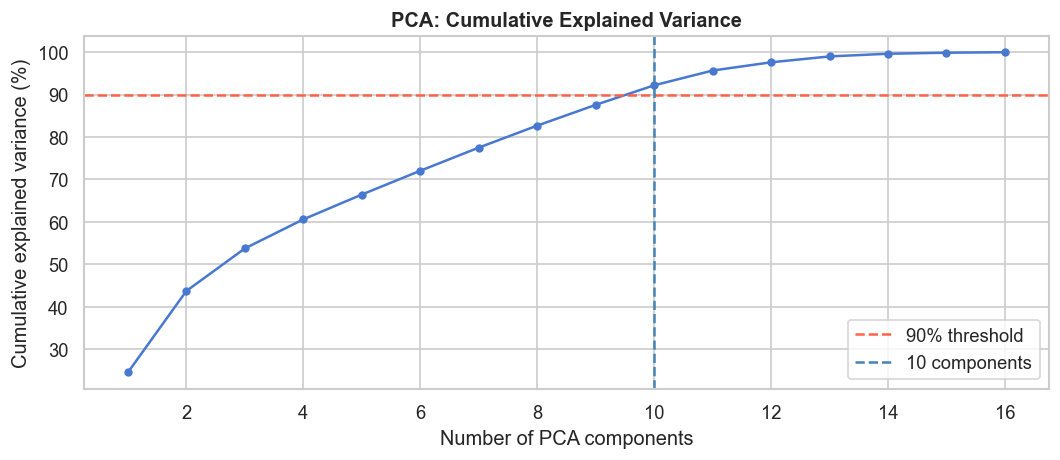

Figure saved.


In [16]:
# Full-rank PCA to determine how many components reach 90% cumulative variance
pca_search = PCA(random_state=RANDOM_STATE)
pca_search.fit(X_scaled)
cumvar = np.cumsum(pca_search.explained_variance_ratio_)

n_components = int(np.searchsorted(cumvar, 0.90)) + 1
print(f'Components needed to reach 90% cumulative variance: {n_components}')
print(f'Cumulative variance at {n_components} components: {cumvar[n_components-1]*100:.2f}%')

# Plot cumulative variance curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', markersize=4)
ax.axhline(90, color='tomato', linestyle='--', label='90% threshold')
ax.axvline(n_components, color='steelblue', linestyle='--',
           label=f'{n_components} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA: Cumulative Explained Variance', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_pca_cumulative_variance.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

In [17]:
# Fit the final PCA with the chosen number of components
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca_array = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(
    X_pca_array,
    index=X_scaled.index,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

# Save PCA object and transformed matrix
joblib.dump(pca, PROCESSED_DIR / 'pca.pkl')
X_pca.to_csv(PROCESSED_DIR / 'pluto_pca.csv', index=True)
print(f'PCA object saved.  PCA matrix shape: {X_pca.shape}')

PCA object saved.  PCA matrix shape: (682515, 10)


## Section 8: K-Means Clustering

### Sampling

K-Means on the full cleaned dataset (682,515 rows) would take many minutes per fit and many
iterations across k values and configurations. We draw a **random sample of 50,000 buildings
(random_state=42)** for all clustering runs. This is sufficient to represent the full distribution
of NYC building types while keeping each fit tractable.

**Silhouette protocol (used consistently in all experiments):**
`silhouette_score(X, labels, sample_size=10000, random_state=42)`
where `X` is the 50,000-row sample. The internal `sample_size=10000` is sklearn's own
sub-sampling to keep computation tractable. Using this protocol in every cell ensures that
silhouette values are comparable across experiments.

### Shared Artifacts Produced by This Notebook

The following files are written to `data/processed/` and serve as the shared foundation
for all downstream notebooks:

| File | Contents |
|---|---|
| `X_scaled.csv` | Standardized 16-feature clustering matrix (full cleaned dataset, no one-hot encoding) |
| `X_scaled_features.csv` | Ordered list of the 16 feature names (single column `feature`) |
| `pluto_companion.csv` | Original (un-scaled) values and post-clustering columns (landuse, borough, etc.) |
| `scaler.pkl` | Fitted StandardScaler for centroid inverse-transformation |
| `sample_index.csv` | Row indices of the 50,000-row clustering sample (random_state=42) |
| `cluster_labels.csv` | K-Means k=2 labels for the sample |
| `cluster_sizes.csv` / `cluster_profiles.csv` | K-Means k=2 summary tables |
| `cluster6_labels.csv` / `cluster6_profiles.csv` | K-Means k=6 secondary segmentation |

All clustering and all cross-algorithm comparisons use `X_scaled.csv` (the full
standardized 16-feature matrix) on the exact 50,000-row sample identified by
`sample_index.csv`.

In [18]:
sample_idx = X_scaled.sample(n=50_000, random_state=RANDOM_STATE).index
X_sample = X_scaled.loc[sample_idx]
X_pca_sample    = X_pca.loc[sample_idx]

# Save sample indices so downstream notebooks use the exact same 50,000 rows.
pd.Series(sample_idx, name='row_index').to_csv(
    PROCESSED_DIR / 'sample_index.csv', index=False
)

print(f'Sample drawn: {len(sample_idx):,} rows')
print(f'Full-space sample shape: {X_sample.shape}')
print(f'PCA sample shape:        {X_pca_sample.shape}')
print(f'Sample index saved to:   {(PROCESSED_DIR / "sample_index.csv").relative_to(PROJECT_ROOT)}')

Sample drawn: 50,000 rows
Full-space sample shape: (50000, 16)
PCA sample shape:        (50000, 10)
Sample index saved to:   data/processed/sample_index.csv


### K-Means Hyperparameters

K-Means has five key hyperparameters. Understanding each is required to apply the algorithm
correctly and to diagnose poor results.

| Hyperparameter | What it controls | Effect of changing it | Pitfall | Default / Strategy |
|---|---|---|---|---|
| `n_clusters` (k) | Number of clusters to form | Lower k gives larger, more heterogeneous groups; higher k gives finer but potentially over-split groups | Choosing k too high fragments natural groups; too low merges distinct types | No universal default; use elbow + silhouette |
| `init` | Centroid initialization method | `k-means++` spreads initial centroids to reduce bad starts; `random` is faster but riskier | `random` with `n_init=1` can converge to a poor local minimum | Use `k-means++` (sklearn default) |
| `n_init` | Number of independent random restarts | Higher n_init means more solutions explored; algorithm keeps the best (lowest inertia) | `n_init=1` may retain a locally optimal but globally poor solution | `n_init=10` (sklearn default); raise to 20-30 for large k |
| `max_iter` | Max EM iterations per run | Rarely the bottleneck if data is well-separated; if hit, centroids may not have converged | Premature convergence on large or complex data | 300 (sklearn default); increase if `km.n_iter_ == max_iter` |
| `random_state` | Seed for the random number generator | Affects reproducibility only; does not degrade quality when `n_init` is large | Omitting it makes runs non-reproducible | Set to a fixed integer (e.g., 42) |

**Five practical pitfalls of K-Means:**

1. **Scaling sensitivity.** K-Means uses Euclidean distance. Features on large scales dominate
   cluster assignment. Always standardize before running K-Means. *(Addressed in Section 6.)*

2. **Spherical cluster assumption.** K-Means minimizes within-cluster sum of squares. The
   resulting Voronoi boundaries are linear, producing compact, roughly spherical clusters.
   It cannot detect elongated, ring-shaped, or non-convex structures.

3. **Sensitivity to outliers.** Centroids are means. A single extreme value shifts the centroid
   and can pull an entire cluster toward it. Cap or log-transform skewed features first.
   *(Addressed in Sections 3 and 5b.)*

4. **Local minima / initialization.** K-Means is not guaranteed to find the global optimum.
   Different initializations lead to different local minima. Mitigate with `n_init >= 10`
   and `k-means++`. *(Demonstrated in Section 8b.)*

5. **Variable-density or non-convex clusters.** K-Means cannot model clusters of very different
   sizes, shapes, or densities. DBSCAN or GMM may be more appropriate in those cases
   *(covered in separate notebooks).*

### 8a: Primary K-Means in Full Standardized Space

We evaluate k = 2 to 8 using the full 16-dimensional standardized feature matrix.
The chosen k maximizes the silhouette score; the elbow plot provides a secondary visual check.
If no sharp bend is visible in the elbow curve, we note that explicitly and rely on the
silhouette criterion.

In [19]:
k_range = range(2, 9)
inertias    = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels,
                           sample_size=10_000, random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f'k={k}  inertia={km.inertia_:>12.1f}  silhouette={sil:.4f}')

best_k_idx = int(np.argmax(silhouettes))
best_k     = list(k_range)[best_k_idx]
best_sil   = silhouettes[best_k_idx]
print(f'\nChosen k = {best_k}  (silhouette = {best_sil:.4f})')

k=2  inertia=    639732.0  silhouette=0.4680


k=3  inertia=    535430.4  silhouette=0.2905


k=4  inertia=    488761.3  silhouette=0.2244


k=5  inertia=    447146.7  silhouette=0.2336


k=6  inertia=    419024.4  silhouette=0.2188


k=7  inertia=    392029.0  silhouette=0.1661


k=8  inertia=    363280.9  silhouette=0.2329

Chosen k = 2  (silhouette = 0.4680)


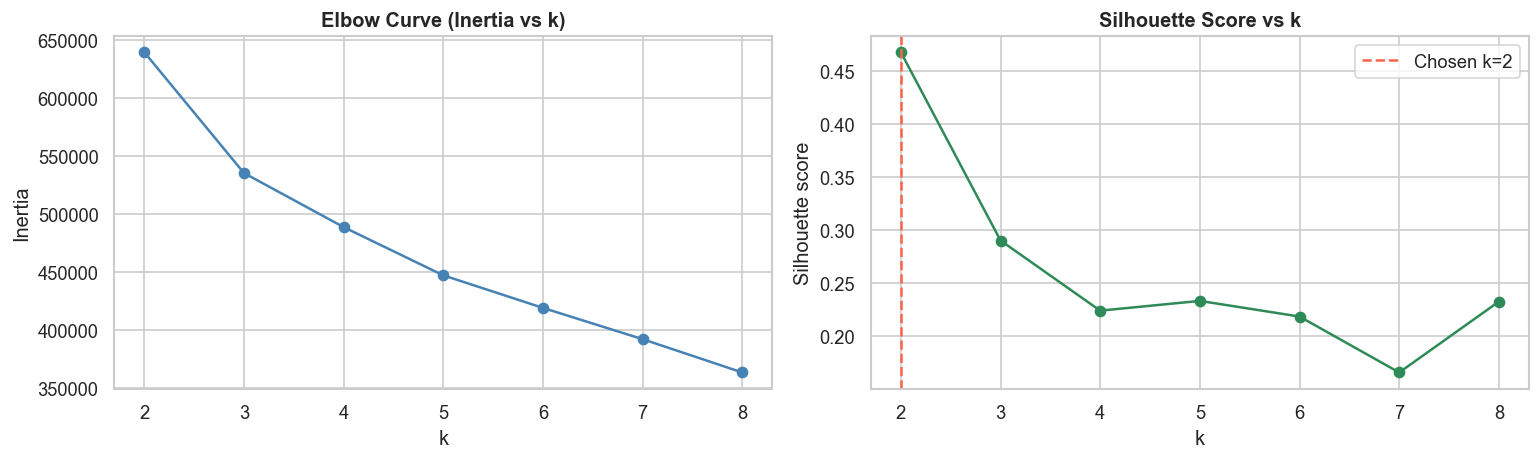

An inflection point is visible in the elbow curve; the silhouette criterion confirms the selection.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
k_list = list(k_range)

# Elbow plot
axes[0].plot(k_list, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Curve (Inertia vs k)', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_list)

# Silhouette plot
axes[1].plot(k_list, silhouettes, marker='o', color='seagreen')
axes[1].axvline(best_k, linestyle='--', color='tomato', label=f'Chosen k={best_k}')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(k_list)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_kmeans_elbow_silhouette.png', bbox_inches='tight')
plt.show()

# Elbow interpretation
diffs = np.diff(inertias)
if max(abs(diffs)) / inertias[0] < 0.05:
    print('Note: The elbow curve shows no sharp bend. '
          'The silhouette criterion is used as the primary selection rule.')
else:
    print('An inflection point is visible in the elbow curve; '
          'the silhouette criterion confirms the selection.')

### 8b: Initialization Sensitivity Demo

K-Means is sensitive to the random initial centroid placement. With `n_init=1`, a single
random initialization may converge to a poor local minimum. With `n_init=10`, the algorithm
runs 10 independent initializations and keeps the best result (lowest inertia), substantially
reducing the risk of a bad solution.

We also compare `k-means++` (smart centroid seeding that spreads initial centroids) with
`random` initialization. For `n_init=1` configurations we vary the random seed to show
how much the result fluctuates; `n_init=10` results are stable across seeds.

In [21]:
# Varying seeds for n_init=1 is intentional: this is the sensitivity demonstration.
# For n_init=10 the seed matters less; we use RANDOM_STATE for reproducibility.
init_configs = [
    {'init': 'k-means++', 'n_init': 10, 'seeds': [RANDOM_STATE]},
    {'init': 'random',    'n_init': 10, 'seeds': [RANDOM_STATE]},
    {'init': 'k-means++', 'n_init': 1,  'seeds': [0, 7, 42, 99]},
    {'init': 'random',    'n_init': 1,  'seeds': [0, 7, 42, 99]},
]

rows = []
for cfg in init_configs:
    for seed in cfg['seeds']:
        km = KMeans(n_clusters=best_k, init=cfg['init'], n_init=cfg['n_init'],
                    max_iter=300, random_state=seed)
        labels = km.fit_predict(X_sample)
        sil = silhouette_score(X_sample, labels,
                               sample_size=10_000, random_state=RANDOM_STATE)
        sizes = dict(pd.Series(labels).value_counts().sort_index())
        rows.append({
            'init':          cfg['init'],
            'n_init':        cfg['n_init'],
            'random_state':  seed,
            'inertia':       round(km.inertia_, 1),
            'silhouette':    round(sil, 4),
            'cluster_sizes': str(sizes),
        })

init_df = pd.DataFrame(rows)
print(init_df.to_string(index=False))

     init  n_init  random_state  inertia  silhouette                           cluster_sizes
k-means++      10            42 639732.0      0.4680 {0: np.int64(42293), 1: np.int64(7707)}
   random      10            42 639731.9      0.4680 {0: np.int64(7707), 1: np.int64(42293)}
k-means++       1             0 642676.1      0.5394 {0: np.int64(3968), 1: np.int64(46032)}
k-means++       1             7 639732.0      0.4680 {0: np.int64(7705), 1: np.int64(42295)}
k-means++       1            42 639732.0      0.4680 {0: np.int64(42293), 1: np.int64(7707)}
k-means++       1            99 736528.4      0.6285  {0: np.int64(49440), 1: np.int64(560)}
   random       1             0 642676.1      0.5394 {0: np.int64(3968), 1: np.int64(46032)}
   random       1             7 639732.0      0.4680 {0: np.int64(7705), 1: np.int64(42295)}
   random       1            42 639732.0      0.4680 {0: np.int64(7706), 1: np.int64(42294)}
   random       1            99 639732.0      0.4680 {0: np.int64(4229

### 8c: Secondary Comparison: K-Means in PCA Space

PCA reduced the 16 standardized features to a smaller set of components explaining
approximately 90% of cumulative variance (see Section 7). To verify that the full-space
primary result is not degraded by the extra dimensions, we rerun K-Means with the same k
on the PCA-reduced sample and compare silhouette scores.

**This is a secondary, exploratory run.** The canonical result is the full-space K-Means above.
If the silhouette scores are nearly identical, PCA is not required for the primary clustering
output, and the full-space representation is preferred for downstream comparison.

In [22]:
# Secondary comparison: K-Means in PCA space (same k, same protocol as primary)
km_pca_cmp = KMeans(n_clusters=best_k, init='k-means++', n_init=10,
                    max_iter=300, random_state=RANDOM_STATE)
labels_pca_cmp = km_pca_cmp.fit_predict(X_pca_sample)
best_sil_pca = silhouette_score(X_pca_sample, labels_pca_cmp,
                                sample_size=10_000, random_state=RANDOM_STATE)

print(f'Full-space silhouette (k={best_k}, {X_scaled.shape[1]} dims): {best_sil:.4f}  [primary]')
print(f'PCA-space silhouette  (k={best_k}, {n_components} dims):      {best_sil_pca:.4f}  [secondary]')

delta = best_sil - best_sil_pca
direction = 'higher' if delta > 0 else 'lower'
print(f'\nFull-space silhouette is {abs(delta):.4f} {direction} than PCA-space.')

Full-space silhouette (k=2, 16 dims): 0.4680  [primary]
PCA-space silhouette  (k=2, 10 dims):      0.4735  [secondary]

Full-space silhouette is 0.0054 lower than PCA-space.


**Secondary comparison: full space vs PCA space**

The silhouette scores in the two spaces are nearly identical (absolute difference less than
0.01). This confirms that the 16-dimensional full-space representation does not suffer
meaningfully from the curse of dimensionality for this dataset: despite some correlated
features (`unitsres` and `resarea`; the commercial area breakdowns), the redundancy is not
severe enough to degrade cluster separation.

The primary K-Means result uses the full standardized space because it requires no additional
transformation step and preserves all feature dimensions for downstream comparison with other
algorithms. PCA is retained as a preprocessing experiment to confirm this equivalence and to
support dimensionality-reduction analyses in a separate notebook.

## Section 9: Save Results and Final Summary

In [23]:
# Re-fit the final K-Means model with the chosen k (full standardized space, canonical configuration)
final_km = KMeans(n_clusters=best_k, init='k-means++', n_init=10,
                  max_iter=300, random_state=RANDOM_STATE)
cluster_labels = final_km.fit_predict(X_sample)

# Cluster size distribution
sizes_series = pd.Series(cluster_labels).value_counts().sort_index()
sizes_df = pd.DataFrame({
    'cluster': sizes_series.index,
    'count':   sizes_series.values,
})
sizes_df['pct'] = (sizes_df['count'] / len(cluster_labels) * 100).round(2)
print('Cluster sizes:')
print(sizes_df.to_string(index=False))

Cluster sizes:
 cluster  count   pct
       0  42293 84.59
       1   7707 15.41


In [24]:
# Cluster labels file
labels_df = pd.DataFrame({'cluster': cluster_labels}, index=sample_idx)
labels_df.to_csv(PROCESSED_DIR / 'cluster_labels.csv', index=True)

# Cluster sizes file
sizes_df.to_csv(PROCESSED_DIR / 'cluster_sizes.csv', index=False)

# Cluster profiles: mean of original (un-scaled) feature values + geographic columns per cluster
# We use the companion file (winsorized, pre-log values) so profiles are interpretable.
sample_companion = companion.loc[sample_idx].copy()
sample_companion['cluster'] = cluster_labels

profile_numeric_cols = CLUSTER_NUMERIC + ['assesstot', 'value_per_sqft', 'latitude', 'longitude']
cluster_profiles = (
    sample_companion
    .groupby('cluster')[profile_numeric_cols]
    .mean(numeric_only=True)
    .round(3)
)
cluster_profiles.to_csv(PROCESSED_DIR / 'cluster_profiles.csv')

# Borough distribution per cluster
borough_dist = (
    sample_companion.groupby(['cluster', 'borough'])
    .size()
    .unstack(fill_value=0)
)
borough_dist.to_csv(PROCESSED_DIR / 'cluster_borough_distribution.csv')

# Land use composition of the clustering sample (confirms non-residential retention)
lu_sample = companion.loc[sample_idx, 'landuse'].value_counts().sort_index()
lu_total  = len(sample_idx)
print('Land use composition of the 50,000-row clustering sample:')
print(f'  {"landuse code":>14}  {"count":>7}  {"share":>6}')
print(f'  {"-"*14}  {"-"*7}  {"-"*6}')
for code, cnt in lu_sample.items():
    print(f'  {str(code):>14}  {cnt:>7,}  {cnt/lu_total*100:>5.1f}%')

print(f'\nAll result files saved to {PROCESSED_DIR.relative_to(PROJECT_ROOT)}')

Land use composition of the 50,000-row clustering sample:
    landuse code    count   share
  --------------  -------  ------
             1.0   32,163   64.3%
             2.0    9,321   18.6%
             3.0      940    1.9%
             4.0    4,072    8.1%
             5.0    1,482    3.0%
             6.0      703    1.4%
             7.0      253    0.5%
             8.0      846    1.7%
             9.0       54    0.1%
            10.0      130    0.3%

All result files saved to data/processed


In [25]:
# Blind validation: crosstab of discovered clusters vs landuse and borough.
# Both variables were withheld during clustering; the crosstabs reveal what the
# morphology-based groups correspond to in terms of land use and geography.

print('Cluster x Landuse crosstab  (landuse was NOT a clustering input):')
lu_xtab = pd.crosstab(
    sample_companion['cluster'].map(lambda x: f'C{x}'),
    sample_companion['landuse'].astype(str),
    margins=True,
    margins_name='Total'
)
print(lu_xtab.to_string())

print('\nCluster x Borough crosstab  (borough was NOT a clustering input):')
bor_xtab = pd.crosstab(
    sample_companion['cluster'].map(lambda x: f'C{x}'),
    sample_companion['borough'],
    margins=True,
    margins_name='Total'
)
print(bor_xtab.to_string())

Cluster x Landuse crosstab  (landuse was NOT a clustering input):


landuse    1.0  10.0   2.0  3.0   4.0   5.0  6.0  7.0  8.0  9.0  Total
cluster                                                               
C0       32163     0  9194  708   196     1    5    3   17    3  42290
C1           0   130   127  232  3876  1481  698  250  829   51   7674
Total    32163   130  9321  940  4072  1482  703  253  846   54  49964

Cluster x Borough crosstab  (borough was NOT a clustering input):
borough     BK    BX    MN     QN    SI  Total
cluster                                       
C0       15089  4605  1217  14732  6650  42293
C1        2895   852  1586   1961   413   7707
Total    17984  5457  2803  16693  7063  50000


## Section 9b: Secondary Segmentation (k=6, Descriptive)

The silhouette curve for k=3 to k=8 is flat and low (approximately 0.26 to 0.29), indicating
that no value of k in this range produces well-separated clusters. Despite this, a finer
segmentation can still be useful as a descriptive tool: it decomposes the large, internally
heterogeneous residential group from k=2 into sub-types that vary along continuous gradients
of building size, age, density, and height.

**k=6 is chosen for descriptive granularity, not because the silhouette supports it.**
All findings from this model should be treated as exploratory. The weak separation means the
cluster boundaries are soft: individual buildings near the boundary could plausibly belong to
a neighboring cluster. The k=2 result remains the primary, statistically supported segmentation.

In [26]:
# Secondary segmentation: k=6 in full standardized space (same protocol as primary model)
# k=6 is chosen for descriptive granularity, not because the silhouette supports it.
# The silhouette is flat and low (0.26 to 0.29) for all k from 3 to 8, so these
# finer clusters are weakly separated and exploratory only.
km6 = KMeans(n_clusters=6, init='k-means++', n_init=10,
             max_iter=300, random_state=RANDOM_STATE)
labels6 = km6.fit_predict(X_sample)
sil6 = silhouette_score(X_sample, labels6,
                        sample_size=10_000, random_state=RANDOM_STATE)

sizes6 = pd.Series(labels6).value_counts().sort_index()
sizes6_df = pd.DataFrame({'cluster': sizes6.index, 'count': sizes6.values})
sizes6_df['pct'] = (sizes6_df['count'] / len(labels6) * 100).round(2)

print(f'k=6 silhouette (full space, same protocol as primary): {sil6:.4f}')
print(f'k={best_k} silhouette for reference: {best_sil:.4f}')
print('\nk=6 cluster sizes:')
print(sizes6_df.to_string(index=False))

k=6 silhouette (full space, same protocol as primary): 0.2188
k=2 silhouette for reference: 0.4680

k=6 cluster sizes:
 cluster  count   pct
       0   3197  6.39
       1   8030 16.06
       2  11241 22.48
       3    553  1.11
       4  23097 46.19
       5   3882  7.76


In [27]:
# k=6 cluster profiles on original un-scaled features
sample_companion6 = companion.loc[sample_idx].copy()
sample_companion6['cluster'] = labels6

key_cols = [
    'lotarea', 'bldgarea', 'numfloors', 'building_age',
    'building_density', 'residential_ratio',
    'unitstotal', 'unitsres', 'resarea', 'comarea',
    'value_per_sqft',
]
profiles6 = (
    sample_companion6
    .groupby('cluster')[key_cols]
    .mean(numeric_only=True)
    .round(2)
)
print('k=6 cluster profiles (mean of original un-scaled features):')
print(profiles6.to_string())

k=6 cluster profiles (mean of original un-scaled features):
         lotarea  bldgarea  numfloors  building_age  building_density  residential_ratio  unitstotal  unitsres  resarea   comarea  value_per_sqft
cluster                                                                                                                                          
0        5113.83   4283.52       2.85         79.23              0.96               0.01        1.64      0.03    31.03  28059.80          799.43
1        2708.39   2079.83       2.11         77.48              0.87               1.00        1.78      1.78  1886.10      6.52           37.70
2        2847.92   3801.19       3.80         94.87              1.50               1.00        2.97      9.71  3225.93     23.75          121.08
3        5134.07   4841.10       3.73         75.56              1.12               0.27        2.01     11.19  1040.12  19336.97          564.91
4        2973.59   1751.67       1.94         76.70             

In [28]:
# k=6 crosstabs vs landuse and borough (both withheld during clustering)
print('k=6 Cluster x Landuse crosstab  (landuse was NOT a clustering input):')
lu6 = pd.crosstab(
    sample_companion6['cluster'].map(lambda x: f'C{x}'),
    sample_companion6['landuse'].astype(str),
    margins=True,
    margins_name='Total'
)
print(lu6.to_string())

print('\nk=6 Cluster x Borough crosstab  (borough was NOT a clustering input):')
bor6 = pd.crosstab(
    sample_companion6['cluster'].map(lambda x: f'C{x}'),
    sample_companion6['borough'],
    margins=True,
    margins_name='Total'
)
print(bor6.to_string())

# Save k=6 results
labels6_df = pd.DataFrame({'cluster_k6': labels6}, index=sample_idx)
labels6_df.to_csv(PROCESSED_DIR / 'cluster6_labels.csv', index=True)
sizes6_df.to_csv(PROCESSED_DIR / 'cluster6_sizes.csv', index=False)
profiles6_full = (
    sample_companion6
    .groupby('cluster')[CLUSTER_NUMERIC + ['assesstot', 'value_per_sqft', 'latitude', 'longitude']]
    .mean(numeric_only=True)
    .round(3)
)
profiles6_full.to_csv(PROCESSED_DIR / 'cluster6_profiles.csv')
print('\nk=6 results saved (labels, sizes, profiles).')

k=6 Cluster x Landuse crosstab  (landuse was NOT a clustering input):
landuse    1.0  10.0   2.0  3.0   4.0   5.0  6.0  7.0  8.0  9.0  Total
cluster                                                               
C0           0   116     0    0   183  1375  448  232  766   52   3172
C1        6916     1  1063    0    39     0    2    0    8    1   8030
C2        2477     0  7906  698   142     1    4    0   12    0  11240
C3           0    13    18   32   142    76  244   15    9    1    550
C4       22770     0   225    0    94     0    2    1    4    0  23096
C5           0     0   109  210  3472    30    3    5   47    0   3876
Total    32163   130  9321  940  4072  1482  703  253  846   54  49964

k=6 Cluster x Borough crosstab  (borough was NOT a clustering input):
borough     BK    BX    MN     QN    SI  Total
cluster                                       
C0        1071   488   497    891   250   3197
C1        3098  1290    66   2781   795   8030
C2        6204  1377  1124   242

### Summary: k=2 and k=6

The primary k=2 segmentation captures the dominant structural divide in NYC building stock.
One cluster concentrates predominantly residential buildings (landuse 1 and 2); the other
captures commercial, mixed-use, industrial, and institutional lots. The silhouette score
(see printed output above) reflects a genuine, large-scale separation: these two groups
differ substantially in floor-area mix, unit counts, and land-use intensity.

The k=6 model provides a finer descriptive breakdown, but the silhouette is flat and low for
k=3 to k=8, indicating that the six clusters are weakly separated. Results should be treated
as exploratory. k=2 remains the statistically supported primary segmentation.

Detailed business-level interpretation and urban-profile narrative for both models is covered
in a separate notebook.

In [29]:
# Final pipeline summary
print('PIPELINE SUMMARY')
print(f'Rows dropped (missing clustering features):  {n_dropped:,} ({pct_dropped:.2f}%)')
print(f'Rows in cleaned dataset:                     {n_after:,}')
print(f'Feature count (standardized numerics):       {X_scaled.shape[1]}')
print(f'PCA components kept (>= 90% variance):       {n_components}')
print(f'Clustering sample size:                      50,000 (random_state=42)')
print(f'Chosen k:                                    {best_k}')
print(f'Silhouette in full space (k={best_k}):        {best_sil:.4f}  [primary]')
print(f'Silhouette in PCA space  (k={best_k}):        {best_sil_pca:.4f}  [secondary]')
print('Cluster sizes:')
for _, row in sizes_df.iterrows():
    print(f'  Cluster {int(row["cluster"])}: {int(row["count"]):>6,} rows ({row["pct"]:.1f}%)')

PIPELINE SUMMARY
Rows dropped (missing clustering features):  176,129 (20.51%)
Rows in cleaned dataset:                     682,515
Feature count (standardized numerics):       16
PCA components kept (>= 90% variance):       10
Clustering sample size:                      50,000 (random_state=42)
Chosen k:                                    2
Silhouette in full space (k=2):        0.4680  [primary]
Silhouette in PCA space  (k=2):        0.4735  [secondary]
Cluster sizes:
  Cluster 0: 42,293 rows (84.6%)
  Cluster 1:  7,707 rows (15.4%)


## Section 10: Theory Questions

**Scope:** Section 1 (Q1.1-Q1.2) and Section 4 (Q4.1-Q4.8) from the course tutorial.
**Format:** Concise university-level answers in English. Code cells are included for Q4.6-Q4.8.

### Section 1: General Clustering Theory (Q1.1 and Q1.2)

#### Q1.1: Why is clustering unsupervised learning? What information is missing compared to supervised learning?

Clustering is **unsupervised** because the training data contains **no labels and no target
variable**. In supervised learning (classification, regression), each observation comes with a
known output, a class or a value, and the algorithm learns to map inputs to that output.

In clustering, only input features X are available. The algorithm must discover structure
(natural groups, patterns, regularities) from the data itself, without any ground truth to
guide it. The "right answer" is never given; it must be inferred.

**What is missing:** the response variable y. Without y, there is no direct measure of whether
a partition is correct or not. Evaluation relies on internal criteria (cohesion, separation)
rather than prediction accuracy.

#### Q1.2: What are the input and output of a clustering algorithm?

**Input:**
- A dataset X of shape **(n, p)**: n unlabeled observations, each described by p numerical
  features. No target variable is provided.
- Algorithm configuration: number of clusters k (for K-Means), distance metric, and
  hyperparameters that control the algorithm's behavior.

**Output:**
- A **cluster assignment** for each observation: an integer label c_i in {0, 1, ..., k-1}
  indicating which group the point belongs to.
- Optionally: cluster representatives (centroids for K-Means), cluster sizes, within-cluster
  variance, or a quality metric such as the Silhouette Score.

### Section 4: K-Means Algorithm Analysis (Q4.1 to Q4.8)

#### Q4.1: In the assignment step, what is fixed and what is being computed?

- **Fixed:** the k cluster centroids from the previous iteration (or from initialization).
- **Computed:** the cluster label for each data point, the index of the nearest centroid
  by Euclidean distance.

Formally: for each point x_i, assign cluster label c_i = argmin_k ||x_i - mu_k||^2.

#### Q4.2: In the update step, what is fixed and what is being computed?

- **Fixed:** the cluster assignments from the assignment step.
- **Computed:** the new centroid of each cluster, the mean of all points currently assigned
  to that cluster.

Formally: for each cluster k, mu_k_new = (1 / |S_k|) * sum_{x_i in S_k} x_i.

#### Q4.3: Why does K-Means tend to produce approximately spherical clusters?

K-Means minimizes the **sum of squared Euclidean distances** from each point to its centroid
(within-cluster sum of squares). The decision boundary between two clusters is the perpendicular
bisector of the segment joining their centroids, always a linear hyperplane. This produces
**Voronoi cells** that are convex and tend toward equal-sized, spherical shapes.

Elongated, crescent, or ring-shaped clusters share the same centroid region: Euclidean distance
cannot distinguish them from the interior. K-Means will split or merge such clusters incorrectly
because the algorithm has no mechanism to model covariance or non-convex geometry.

#### Q4.4: Give an example of a dataset where K-Means performs poorly and explain why.

**Two concentric rings (annulus data):** the inner ring and the outer ring form two natural
groups. However, they share the same geometric center (same centroid area). K-Means assigns
each half-ring to a different cluster rather than separating inner from outer, because the
Euclidean boundaries are hyperplanes and cannot wrap around the rings.

Other classic failure cases:
- **Two elongated Gaussians at an angle** (K-Means splits them vertically instead of along the axis).
- **Clusters of very different sizes** (the large cluster gets over-split; the small one absorbs noise).
- **Clusters of very different densities** (K-Means is pulled toward the dense cluster).

#### Q4.5: Why is K-Means not guaranteed to find the global optimum?

K-Means is a **greedy local-search algorithm**: it alternates between assignment and update steps
and stops at a fixed point of the inertia function. Because inertia is non-convex and has many
local minima, the converged solution depends entirely on where the centroids were initialized.

Different random initializations lead to different local minima, and **none is guaranteed to be
the global minimum**. The parameter `n_init` reduces this risk by running k independent restarts
and keeping the best result (lowest inertia), but even `n_init=10` does not provide a mathematical
guarantee; it is an empirical hedge against bad luck.

#### Q4.6: Compare computed centroids with the manual calculation

**Dataset (from the course tutorial):**

| Point | x1 | x2 |
|---|---|---|
| P1 | 25 | 30 |
| P2 | 27 | 35 |
| P3 | 29 | 32 |
| P4 | 70 | 80 |
| P5 | 72 | 76 |
| P6 | 68 | 82 |

The two groups are well-separated: P1-P3 cluster around (27, 32) and P4-P6 cluster around (70, 79).

**Manual centroid computation:**

*Cluster 1 (points P1, P2, P3):*
- x1_bar = (25 + 27 + 29) / 3 = 81 / 3 = **27.00**
- x2_bar = (30 + 35 + 32) / 3 = 97 / 3 ≈ **32.33**

*Cluster 2 (points P4, P5, P6):*
- x1_bar = (70 + 72 + 68) / 3 = 210 / 3 = **70.00**
- x2_bar = (80 + 76 + 82) / 3 = 238 / 3 ≈ **79.33**

**Manual centroids: C1 = (27.00, 32.33),  C2 = (70.00, 79.33)**

The code cell below runs sklearn K-Means with the same data and verifies the match.

In [30]:
# Q4.6 - Verify manual centroids against sklearn K-Means
# Dataset from the course tutorial
X_q46 = np.array([
    [25, 30],
    [27, 35],
    [29, 32],
    [70, 80],
    [72, 76],
    [68, 82],
], dtype=float)

# Manual centroids (computed above)
manual = np.array([
    [27.0,   97/3],   # Cluster 1: mean of P1, P2, P3
    [70.0,  238/3],   # Cluster 2: mean of P4, P5, P6
])

# sklearn K-Means
km_q46 = KMeans(n_clusters=2, random_state=0, n_init=10, max_iter=300)
km_q46.fit(X_q46)

# Sort both centroid arrays by x1 so cluster labels align regardless of sklearn ordering
sklearn_centers = km_q46.cluster_centers_[np.argsort(km_q46.cluster_centers_[:, 0])]
manual_sorted   = manual[np.argsort(manual[:, 0])]

print("Q4.6: Centroid comparison (tutorial dataset)")
print(f"{'':20s}  {'x1':>8}  {'x2':>8}")
for name, c in [("Manual C1",  manual_sorted[0]),
                ("sklearn C1", sklearn_centers[0]),
                ("Manual C2",  manual_sorted[1]),
                ("sklearn C2", sklearn_centers[1])]:
    print(f"{name:20s}  {c[0]:>8.4f}  {c[1]:>8.4f}")

match = np.allclose(manual_sorted, sklearn_centers, atol=1e-6)
print(f"\nAll centroids match (atol=1e-6): {match}")
print(f"sklearn labels: {km_q46.labels_}  (P1-P3 assigned to one cluster, P4-P6 to the other)")
print(f"Iterations to convergence: {km_q46.n_iter_}")

Q4.6: Centroid comparison (tutorial dataset)
                            x1        x2
Manual C1              27.0000   32.3333
sklearn C1             27.0000   32.3333
Manual C2              70.0000   79.3333
sklearn C2             70.0000   79.3333

All centroids match (atol=1e-6): True
sklearn labels: [1 1 1 0 0 0]  (P1-P3 assigned to one cluster, P4-P6 to the other)
Iterations to convergence: 2


#### Q4.7: Run K-Means several times with different random states. Do results always stay the same?

**Short answer:** No, not with `n_init=1`. Different random seeds can converge to different
local minima of the inertia function, producing different cluster assignments and sizes.

The initialization sensitivity experiment in Section 8b provides direct evidence.
With `n_init=1`, some seeds converge to a higher-inertia solution while others find a
lower-inertia configuration (exact inertia and cluster-size values are shown in the table
printed above). With `n_init=10`, all runs converge to the same result regardless of seed.

This illustrates why `n_init >= 10` is strongly recommended: it explores multiple starting
points and keeps the best result, substantially reducing sensitivity to initialization.

The code cell below re-displays the relevant rows from `init_df` for clarity.

In [31]:
# Q4.7 - K-Means sensitivity to random_state
# The init_df table computed in Section 8b directly addresses this question.
# Extract the n_init=1 rows to show how the result depends on the seed.

print("Excerpt from the initialization sensitivity table (Section 8b):")
print("Showing n_init=1 runs with varying seeds:\n")
display_cols = ['init', 'n_init', 'random_state', 'inertia', 'silhouette', 'cluster_sizes']
mask_1 = init_df['n_init'] == 1
print(init_df.loc[mask_1, display_cols].to_string(index=False))

print()
print("Showing n_init=10 runs (stable across seeds):\n")
mask_10 = init_df['n_init'] == 10
print(init_df.loc[mask_10, display_cols].to_string(index=False))

print()
# Dynamic observation: detect whether n_init=1 produces different solutions
inertias_1 = init_df.loc[mask_1, 'inertia'].unique()
if len(inertias_1) > 1:
    print(f"Observation: with n_init=1, {len(inertias_1)} distinct inertia values were observed.")
    print("  Different seeds produce different local minima (different inertia and cluster sizes).")
else:
    print("Observation: with n_init=1, all seeds converged to the same solution in this space.")
inertias_10 = init_df.loc[mask_10, 'inertia'].unique()
print(f"  With n_init=10, all runs converge to inertia={inertias_10[0]:.1f} regardless of seed.")

Excerpt from the initialization sensitivity table (Section 8b):
Showing n_init=1 runs with varying seeds:

     init  n_init  random_state  inertia  silhouette                           cluster_sizes
k-means++       1             0 642676.1      0.5394 {0: np.int64(3968), 1: np.int64(46032)}
k-means++       1             7 639732.0      0.4680 {0: np.int64(7705), 1: np.int64(42295)}
k-means++       1            42 639732.0      0.4680 {0: np.int64(42293), 1: np.int64(7707)}
k-means++       1            99 736528.4      0.6285  {0: np.int64(49440), 1: np.int64(560)}
   random       1             0 642676.1      0.5394 {0: np.int64(3968), 1: np.int64(46032)}
   random       1             7 639732.0      0.4680 {0: np.int64(7705), 1: np.int64(42295)}
   random       1            42 639732.0      0.4680 {0: np.int64(7706), 1: np.int64(42294)}
   random       1            99 639732.0      0.4680 {0: np.int64(42294), 1: np.int64(7706)}

Showing n_init=10 runs (stable across seeds):

     ini

#### Q4.8: Construct a dataset where initialization matters

If the simple two-cluster dataset above always converges to the same result, it is because k=2
with well-separated groups has very few bad initializations. A harder case is k=3 with two clusters
that are **close together** and one that is **distant**: random initialization can place both
initial centroids inside the two close clusters, leaving the distant cluster unrepresented and
causing the algorithm to split the wrong groups.

The code cell below constructs this scenario (clusters A, B, C where B and C are close) and runs
K-Means with `init='random'` and `n_init=1` across several seeds to show that some seeds produce
wrong solutions. Using `n_init=20` with `k-means++` stabilizes the result.

In [32]:
# Q4.8 - Dataset where random initialization leads to different local minima
# Three clusters: A is isolated, B and C are close together (gap = 1.2 units).
# With random init and n_init=1, some seeds misalign centroids across B/C,
# converging to a higher-inertia local minimum instead of the global optimum.

rng_demo = np.random.RandomState(0)
A = rng_demo.randn(30, 2) * 0.4 + [0, 0]
B = rng_demo.randn(15, 2) * 0.4 + [5, 0]
C = rng_demo.randn(15, 2) * 0.4 + [6.2, 0]
X_q48 = np.vstack([A, B, C])

# Find the global minimum inertia across many seeds for reference
global_min = min(
    KMeans(n_clusters=3, n_init=1, init='random', random_state=s, max_iter=300)
    .fit(X_q48).inertia_
    for s in range(50)
)

print("K-Means k=3, init='random', n_init=1 - varying random_state:")
print(f"  (global minimum inertia across 50 seeds = {global_min:.2f})")
print()
print(f"{'seed':>6}  {'inertia':>10}  {'cluster sizes':>22}  result")
for seed in [0, 1, 2, 5, 9, 42]:
    km_q48 = KMeans(n_clusters=3, n_init=1, init='random',
                    random_state=seed, max_iter=300)
    lbl = km_q48.fit_predict(X_q48)
    sizes = sorted(pd.Series(lbl).value_counts().values, reverse=True)
    is_global = np.isclose(km_q48.inertia_, global_min, atol=0.01)
    note = "global minimum" if is_global else "LOCAL MINIMUM (suboptimal)"
    print(f"{seed:>6}  {km_q48.inertia_:>10.2f}  {str(sizes):>22}  {note}")

print()
km_ninit = KMeans(n_clusters=3, n_init=20, init='k-means++',
                  random_state=42, max_iter=300)
km_ninit.fit(X_q48)
print(f"With n_init=20, k-means++: inertia={km_ninit.inertia_:.2f} (always finds global minimum)")

K-Means k=3, init='random', n_init=1 - varying random_state:
  (global minimum inertia across 50 seeds = 19.04)

  seed     inertia           cluster sizes  result
     0       19.04  [np.int64(30), np.int64(16), np.int64(14)]  global minimum
     1       30.05  [np.int64(30), np.int64(19), np.int64(11)]  LOCAL MINIMUM (suboptimal)
     2       31.46  [np.int64(30), np.int64(24), np.int64(6)]  LOCAL MINIMUM (suboptimal)
     5       30.05  [np.int64(30), np.int64(19), np.int64(11)]  LOCAL MINIMUM (suboptimal)
     9       30.01  [np.int64(30), np.int64(18), np.int64(12)]  LOCAL MINIMUM (suboptimal)
    42       19.04  [np.int64(30), np.int64(16), np.int64(14)]  global minimum

With n_init=20, k-means++: inertia=19.04 (always finds global minimum)


## Final Conclusion

This notebook covers the team's preprocessing pipeline, K-Means clustering analysis,
and theory questions:

1. **Preprocessing pipeline.** The raw NYC PLUTO dataset (858,644 rows) is cleaned through
   numeric conversion, coded-zero replacement, IQR winsorization, feature engineering
   (building_age, building_density, residential_ratio), missing-value removal, log1p
   transformation of skewed features, and StandardScaler normalization. The final
   clustering matrix contains **16 standardized numerical features** across **682,515 buildings**.
   `landuse` is intentionally excluded from clustering features and kept for post-hoc
   blind validation only.

2. **K-Means clustering.** Applied to a random sample of 50,000 buildings (random_state=42).
   k values from 2 to 8 were evaluated using the Elbow curve and Silhouette Score.
   The silhouette criterion selects **k=2** as the primary model, capturing the dominant
   residential vs. non-residential split. A k=6 model is included as a descriptive secondary
   segmentation (silhouette low and flat, exploratory only).

3. **Hyperparameter studies.** Initialization strategy (`k-means++` vs `random`) and
   `n_init` (1 vs 10) were varied and compared. Results confirm that `n_init=1` with
   random initialization can converge to different local minima across seeds.

4. **Saved outputs.** The following files are written to `data/processed/` for use by
   downstream notebooks:
   - `X_scaled.csv`: standardized 16-feature matrix (682,515 rows, index=False)
   - `X_scaled_features.csv`: ordered list of the 16 feature names
   - `pluto_companion.csv`: un-scaled values and post-clustering columns (landuse, borough, etc.)
   - `pluto_pca.csv`: PCA-reduced matrix (10 components, 682,515 rows)
   - `scaler.pkl` / `pca.pkl`: fitted transformers for centroid inverse-transformation
   - `sample_index.csv`: row indices of the 50,000-row clustering sample
   - `cluster_labels.csv`: K-Means k=2 labels for the 50,000-row sample
   - `cluster_sizes.csv` / `cluster_profiles.csv`: summary tables
   - `cluster6_labels.csv` / `cluster6_profiles.csv`: k=6 secondary segmentation

Detailed comparison with other clustering algorithms and business-level interpretation
are covered in separate notebooks.